In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
# =============================================================
# 1. LOAD DATA
# =============================================================
data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/percobaancvd/datasetfix/heart_disease_new_dataset1.csv')
print("Shape awal:", data.shape)
print(data['CVD_LABEL'].value_counts())

Shape awal: (438693, 304)
CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64


In [97]:
# =============================================================
# 2. HAPUS KOLOM MISSING VALUES >= 30%
# =============================================================
miss = data.isnull().mean() * 100
cols_to_drop_miss = miss[miss >= 30].index.tolist()

print(f"\nKolom dihapus karena missing >= 30% ({len(cols_to_drop_miss)}):")
print(cols_to_drop_miss)

data1 = data.drop(columns=cols_to_drop_miss)
print(f"\nShape setelah hapus missing: {data1.shape}")


Kolom dihapus karena missing >= 30% (155):
['CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'COLGSEX', 'NUMADULT', 'LANDSEX', 'NUMMEN', 'NUMWOMEN', 'RESPSLCT', 'CCLGHOUS', 'POORHLTH', 'BPMEDS', 'ASTHNOW', 'DIABAGE3', 'ARTHEXER', 'ARTHEDU', 'LMTJOIN3', 'ARTHDIS2', 'JOINPAI2', 'NUMHHOL3', 'NUMPHON3', 'PREGNANT', 'SMOKDAY2', 'AVEDRNK3', 'DRNK3GE5', 'MAXDRNKS', 'FLSHTMY3', 'IMFVPLA2', 'HIVTSTD3', 'PDIABTST', 'PREDIAB1', 'INSULIN1', 'BLDSUGAR', 'FEETCHK3', 'DOCTDIAB', 'CHKHEMO3', 'FEETCHK', 'EYEEXAM1', 'DIABEYE', 'DIABEDU', 'TOLDCFS', 'HAVECFS', 'WORKCFS', 'TOLDHEPC', 'TRETHEPC', 'PRIRHEPC', 'HAVEHEPC', 'HAVEHEPB', 'MEDSHEPB', 'HPVADVC4', 'HPVADSHT', 'TETANUS1', 'SHINGLE2', 'LCSFIRST', 'LCSLAST', 'LCSNUMCG', 'LCSCTSCN', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'PSATEST1', 'PSATIME1', 'PCPSARS2', 'PCSTALK', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLNCNCR', 'VIRCOLO1', 'VCLNTES1', 'SMALSTOL', 'STOLTEST', 'ST

In [98]:
# ============================================================
# DEFINISI FITUR (sudah deduplikasi)
# ============================================================
fitur_paper = [
    # --- Cardiovascular / Target ---
    'CVD_LABEL',    # Label/Target
    '_MICHD',       # Heart Problems (CHD/MI)
    'CVDSTRK3',     # Stroke
    'CVDCRHD4',     # Coronary Heart Disease
    'CVDINFR4',     # Heart Attack

    # --- Blood Pressure & Cholesterol ---
    '_RFHYPE6',     # High Blood Pressure (calculated)
    'BPHIGH6',      # Ever Told Blood Pressure High
    'TOLDHI3',      # High Cholesterol
    '_CHOLCH3',     # Cholesterol Check (calculated)
    'CHOLCHK3',     # Cholesterol Check (raw)

    # --- Metabolic & Chronic Conditions ---
    'DIABETE4',     # Diabetes
    'CHCKDNY2',     # Kidney Disease
    'CHCCOPD3',     # COPD
    'ASTHMA3',      # Asthma
    'ADDEPEV3',     # Depression
    '_DRDXAR3',     # Arthritis

    # --- BMI ---
    '_BMI5',        # BMI (continuous)
    '_BMI5CAT',     # BMI Category

    # --- Lifestyle ---
    'SMOKE100',     # Smoker
    '_TOTINDA',     # Physical Activity
    '_FRTLT1A',     # Fruits Consumption
    '_VEGLT1A',     # Veggies Consumption
    '_DRNKWK1',     # Alcohol Consumption

    # --- Health Status ---
    'GENHLTH',      # General Health
    'MENTHLTH',     # Mental Health
    'PHYSHLTH',     # Physical Health
    'DIFFWALK',     # Difficulty Walking
    'DECIDE',       # Difficulty Concentrating/Deciding

    # --- Healthcare Access ---
    '_HLTHPLN',     # Any Healthcare Coverage
    'MEDCOST1',     # No Doc because Cost
    'PERSDOC3',     # Personal Doctor
    'CHECKUP1',     # Last Routine Checkup

    # --- Preventive Care ---
    'PNEUVAC4',     # Pneumonia Vaccine
    'FLUSHOT7',     # Flu Shot
    '_AIDTST4',     # HIV Test

    # --- Demographics ---
    '_SEX',         # Sex
    '_AGEG5YR',     # Age Group
    'EDUCA',        # Education
    'INCOME3',      # Income
    'EMPLOY1',      # Employment Status
    '_PRACE1',      # Race
]

# Hapus duplikat sambil pertahankan urutan
fitur_paper = list(dict.fromkeys(fitur_paper))

# ============================================================
# CEK KOLOM DIABETES
# ============================================================
diabetes_cols = [c for c in data1.columns if 'DIAB' in c.upper()]
print("Kolom diabetes yang tersedia:", diabetes_cols)

# ============================================================
# CEK KETERSEDIAAN FITUR
# ============================================================
fitur_exist   = [c for c in fitur_paper if c in data1.columns]
fitur_missing = [c for c in fitur_paper if c not in data1.columns]

print(f"\n{'='*45}")
print(f"  Total fitur didefinisikan : {len(fitur_paper)}")
print(f"  Fitur ditemukan           : {len(fitur_exist)}")
print(f"  Fitur tidak ditemukan     : {len(fitur_missing)}")
print(f"{'='*45}")

if fitur_missing:
    print("\n⚠️  Fitur yang TIDAK ADA di dataset:")
    for i, col in enumerate(fitur_missing, 1):
        print(f"   {i:2}. {col}")

# ============================================================
# BUAT DATASET FINAL
# ============================================================
data_final = data1[fitur_exist].copy()

print(f"\n✅ Shape data final : {data_final.shape}")
print(f"\nFitur yang dipakai ({len(fitur_exist)} fitur):")
for i, col in enumerate(fitur_exist, 1):
    print(f"  {i:2}. {col}")

Kolom diabetes yang tersedia: ['DIABETE4']

  Total fitur didefinisikan : 41
  Fitur ditemukan           : 41
  Fitur tidak ditemukan     : 0

✅ Shape data final : (438693, 41)

Fitur yang dipakai (41 fitur):
   1. CVD_LABEL
   2. _MICHD
   3. CVDSTRK3
   4. CVDCRHD4
   5. CVDINFR4
   6. _RFHYPE6
   7. BPHIGH6
   8. TOLDHI3
   9. _CHOLCH3
  10. CHOLCHK3
  11. DIABETE4
  12. CHCKDNY2
  13. CHCCOPD3
  14. ASTHMA3
  15. ADDEPEV3
  16. _DRDXAR3
  17. _BMI5
  18. _BMI5CAT
  19. SMOKE100
  20. _TOTINDA
  21. _FRTLT1A
  22. _VEGLT1A
  23. _DRNKWK1
  24. GENHLTH
  25. MENTHLTH
  26. PHYSHLTH
  27. DIFFWALK
  28. DECIDE
  29. _HLTHPLN
  30. MEDCOST1
  31. PERSDOC3
  32. CHECKUP1
  33. PNEUVAC4
  34. FLUSHOT7
  35. _AIDTST4
  36. _SEX
  37. _AGEG5YR
  38. EDUCA
  39. INCOME3
  40. EMPLOY1
  41. _PRACE1


## Preprocessing 1

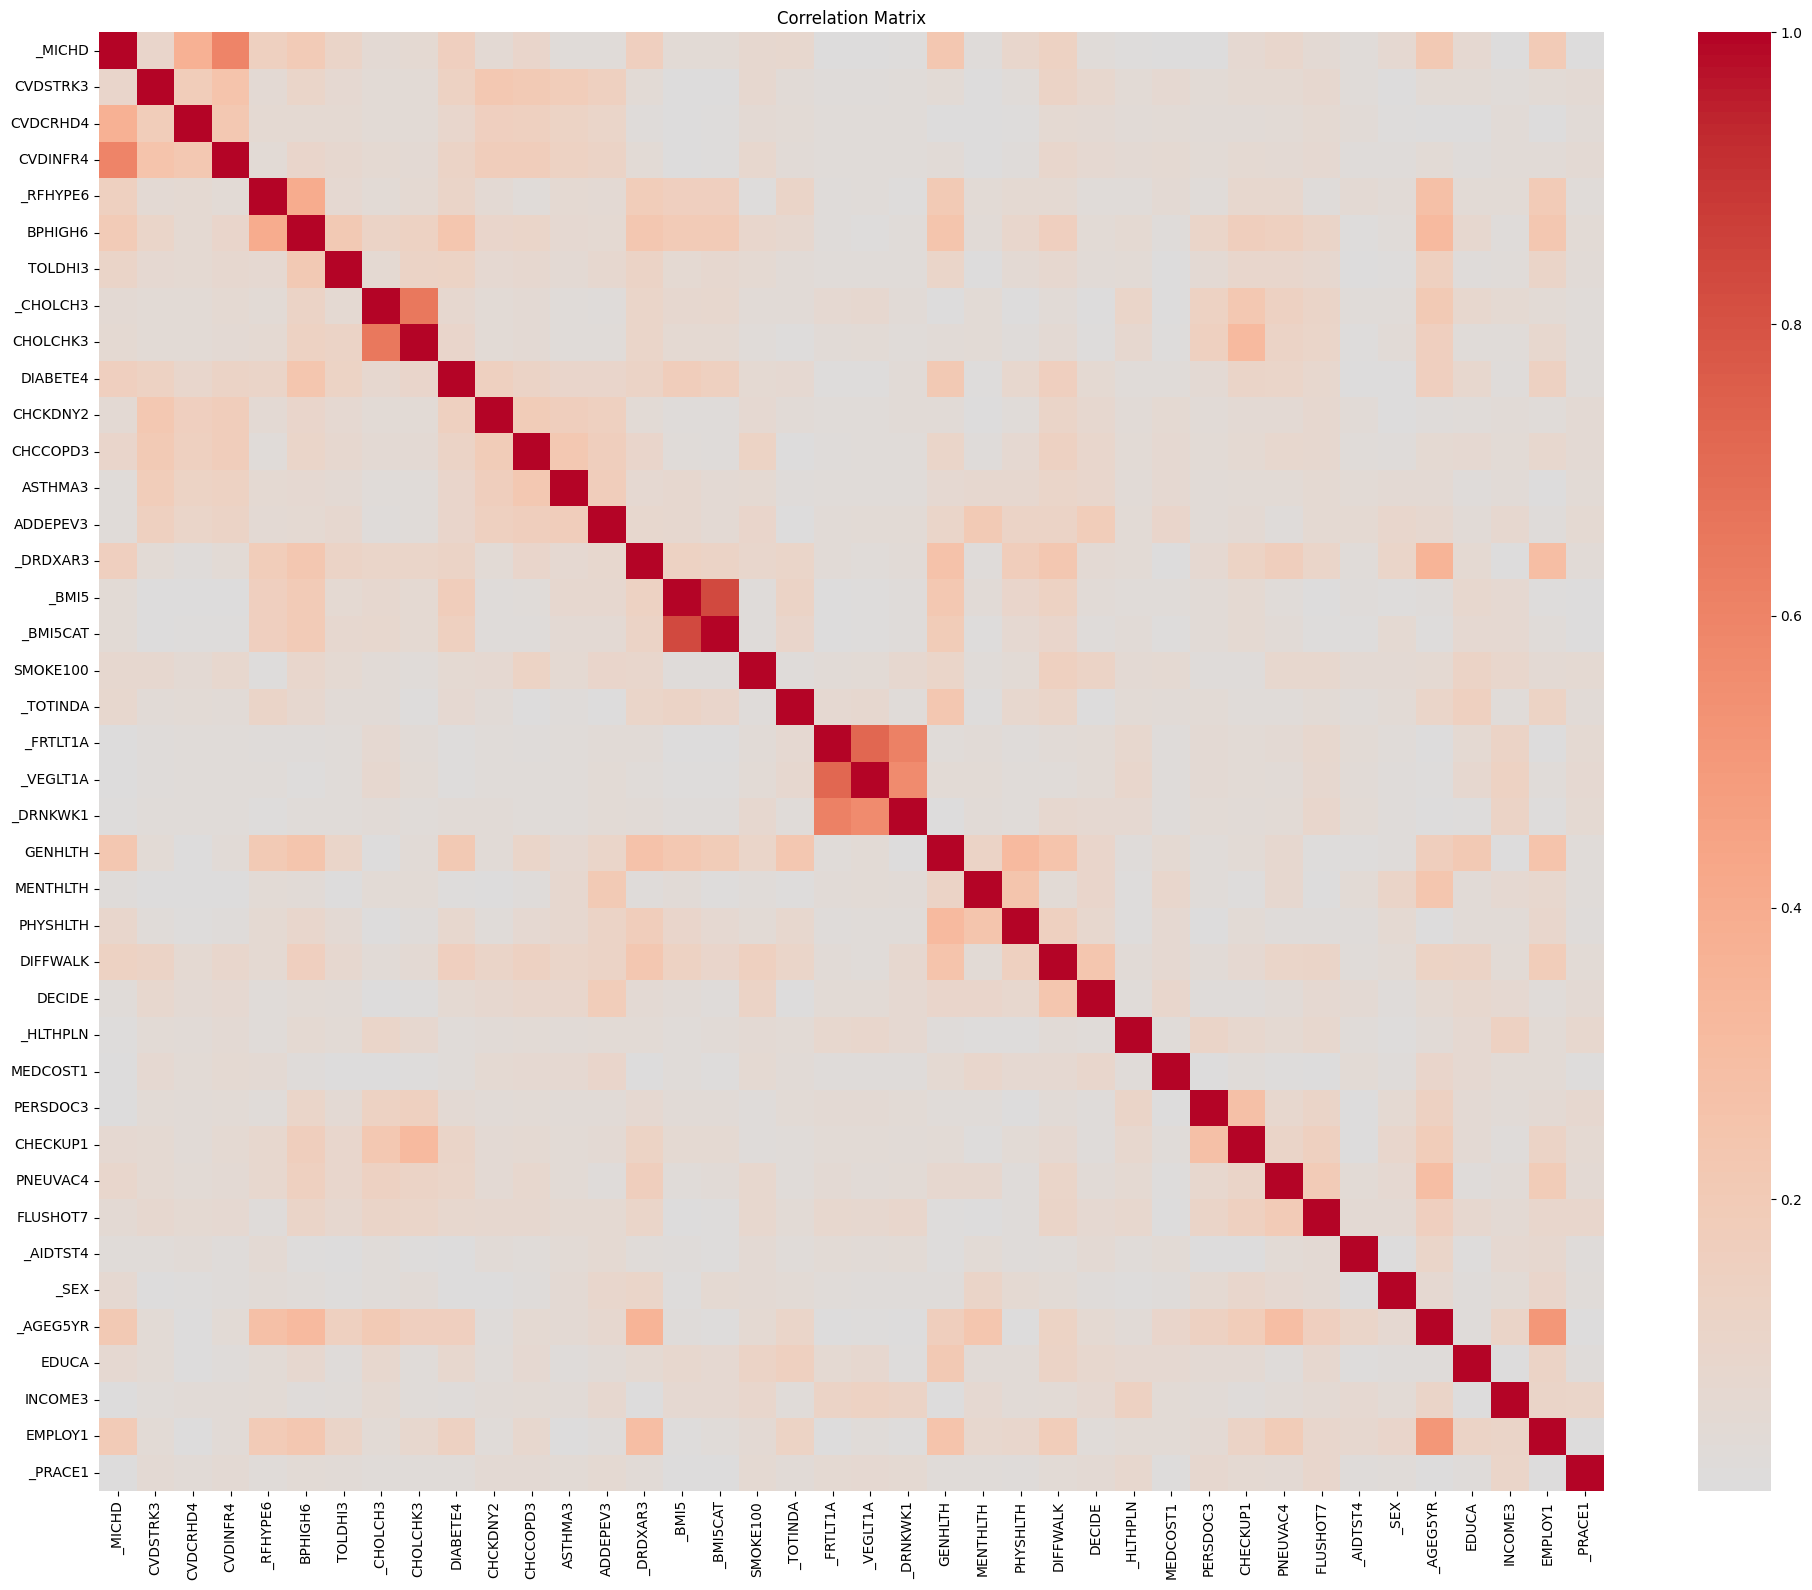

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung korelasi
corr_matrix = data_final.select_dtypes(include='float64').corr().abs()

# Visualisasi heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            cmap='coolwarm',
            center=0,
            annot=False,  # ganti True kalau mau lihat angkanya (lambat kalau banyak fitur)
            fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [100]:
# Tampilkan pasangan fitur dengan korelasi > 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.50]

high_corr_df = pd.DataFrame(high_corr, columns=['Fitur_1', 'Fitur_2', 'Korelasi'])
high_corr_df = high_corr_df.sort_values('Korelasi', ascending=False)

print(f"Pasangan fitur dengan korelasi > 0.85: {len(high_corr_df)}")
print(high_corr_df.to_string(index=False))

Pasangan fitur dengan korelasi > 0.85: 7
 Fitur_1  Fitur_2  Korelasi
_BMI5CAT    _BMI5  0.830420
_VEGLT1A _FRTLT1A  0.721476
CHOLCHK3 _CHOLCH3  0.648654
_DRNKWK1 _FRTLT1A  0.609881
CVDINFR4   _MICHD  0.600431
_DRNKWK1 _VEGLT1A  0.569375
 EMPLOY1 _AGEG5YR  0.511347


In [101]:
data_final = data_final.drop(columns=['_BMI5CAT'])

In [102]:
# Cara 1 - Value counts semua kolom sekaligus
for col in data_final.columns:
    print(f"\n{'='*50}")
    print(f"Kolom: {col}")
    print(data_final[col].value_counts(dropna=False))


Kolom: CVD_LABEL
CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64

Kolom: _MICHD
_MICHD
2.0    398735
1.0     35323
NaN      4635
Name: count, dtype: int64

Kolom: CVDSTRK3
CVDSTRK3
2.0    420051
1.0     17213
7.0      1130
9.0       297
NaN         2
Name: count, dtype: int64

Kolom: CVDCRHD4
CVDCRHD4
2.0    411527
1.0     22891
7.0      3934
9.0       339
NaN         2
Name: count, dtype: int64

Kolom: CVDINFR4
CVDINFR4
2.0    413207
1.0     22831
7.0      2319
9.0       334
NaN         2
Name: count, dtype: int64

Kolom: _RFHYPE6
_RFHYPE6
1.0    264648
2.0    172133
9.0      1912
Name: count, dtype: int64

Kolom: BPHIGH6
BPHIGH6
3.0    256603
1.0    172133
4.0      4571
2.0      3474
7.0      1191
9.0       719
NaN         2
Name: count, dtype: int64

Kolom: TOLDHI3
TOLDHI3


In [103]:
import pandas as pd
import numpy as np

# Nilai yang perlu diganti NaN per variabel
nan_map = {
    'CVDSTRK3':  [7.0, 9.0],
    'CVDCRHD4':  [7.0, 9.0],
    'CVDINFR4':  [7.0, 9.0],
    'BPHIGH6':   [7.0, 9.0],
    'TOLDHI3':   [7.0, 9.0],
    '_CHOLCH3':  [9.0],
    'CHOLCHK3':  [7.0, 9.0],
    'DIABETE4':  [7.0, 9.0],
    'CHCKDNY2':  [7.0, 9.0],
    'CHCCOPD3':  [7.0, 9.0],
    'ASTHMA3':   [7.0, 9.0],
    'ADDEPEV3':  [7.0, 9.0],
    '_DRDXAR3':  [],           # sudah NaN semua
    'SMOKE100':  [7.0, 9.0],
    '_TOTINDA':  [9.0],
    '_FRTLT1A':  [9.0],
    '_VEGLT1A':  [9.0],
    'GENHLTH':   [7.0, 9.0],
    'MENTHLTH':  [77.0, 99.0],
    'PHYSHLTH':  [77.0, 99.0],
    'DIFFWALK':  [7.0, 9.0],
    'DECIDE':    [7.0, 9.0],
    '_HLTHPLN':  [9.0],
    'MEDCOST1':  [7.0, 9.0],
    'PERSDOC3':  [7.0, 9.0],
    'CHECKUP1':  [7.0, 8.0, 9.0],
    'PNEUVAC4':  [7.0, 9.0],
    'FLUSHOT7':  [7.0, 9.0],
    '_AIDTST4':  [9.0],
    'EDUCA':     [9.0],
    'INCOME3':   [77.0, 99.0],
    'EMPLOY1':   [9.0],
    '_PRACE1':   [77.0, 99.0],
}

for col, invalid_vals in nan_map.items():
    if col in data_final.columns and invalid_vals:
        data_final[col] = data_final[col].replace(invalid_vals, np.nan)

print("Selesai! Cek missing values:")
print(data_final[nan_map.keys()].isna().sum())

Selesai! Cek missing values:
CVDSTRK3     1429
CVDCRHD4     4275
CVDINFR4     2655
BPHIGH6      1912
TOLDHI3     63980
_CHOLCH3    29782
CHOLCHK3    29782
DIABETE4      985
CHCKDNY2     1813
CHCCOPD3     2107
ASTHMA3      1746
ADDEPEV3     2517
_DRDXAR3     2896
SMOKE100    24461
_TOTINDA      928
_FRTLT1A    51087
_VEGLT1A    60127
GENHLTH      1161
MENTHLTH     7917
PHYSHLTH     9494
DIFFWALK    19830
DECIDE      19980
_HLTHPLN    17397
MEDCOST1     1364
PERSDOC3     3705
CHECKUP1     8216
PNEUVAC4    62801
FLUSHOT7    31392
_AIDTST4    51856
EDUCA        2478
INCOME3     94413
EMPLOY1      8251
_PRACE1     13363
dtype: int64


In [104]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438693 entries, 0 to 438692
Data columns (total 40 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   CVD_LABEL  438693 non-null  object 
 1   _MICHD     434058 non-null  float64
 2   CVDSTRK3   437264 non-null  float64
 3   CVDCRHD4   434418 non-null  float64
 4   CVDINFR4   436038 non-null  float64
 5   _RFHYPE6   438693 non-null  float64
 6   BPHIGH6    436781 non-null  float64
 7   TOLDHI3    374713 non-null  float64
 8   _CHOLCH3   408911 non-null  float64
 9   CHOLCHK3   408911 non-null  float64
 10  DIABETE4   437708 non-null  float64
 11  CHCKDNY2   436880 non-null  float64
 12  CHCCOPD3   436586 non-null  float64
 13  ASTHMA3    436947 non-null  float64
 14  ADDEPEV3   436176 non-null  float64
 15  _DRDXAR3   435797 non-null  float64
 16  _BMI5      391841 non-null  float64
 17  SMOKE100   414232 non-null  float64
 18  _TOTINDA   437765 non-null  float64
 19  _FRTLT1A   387606 non-n

In [105]:
data_final.describe()

,_MICHD,CVDSTRK3,CVDCRHD4,CVDINFR4,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,DIABETE4,...,CHECKUP1,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,INCOME3,EMPLOY1,_PRACE1
count,434058.000000,437264.000000,434418.000000,436038.000000,438693.000000,436781.000000,374713.000000,408911.000000,408911.000000,437708.000000,...,430477.000000,375892.000000,407301.000000,386837.000000,438693.000000,438693.000000,436215.000000,344280.000000,430442.000000,425330.000000
mean,1.918621,1.960635,1.947307,1.947640,1.427244,2.214323,1.600430,1.186539,2.405142,2.750752,...,1.356802,1.596778,1.479098,1.666506,1.535529,7.726016,5.012790,6.698330,3.747225,1.431935
std,0.273416,0.194463,0.223421,0.222752,0.699127,0.988691,0.489811,0.552422,1.300781,0.704141,...,0.772044,0.490545,0.499564,0.471462,0.498737,3.645926,1.007272,2.422855,2.837228,1.143380
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,4.000000,5.000000,1.000000,1.000000
50%,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,3.000000,...,1.000000,2.000000,1.000000,2.000000,2.000000,8.000000,5.000000,7.000000,2.000000,1.000000
75%,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,3.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,11.000000,6.000000,9.000000,7.000000,1.000000
max,2.000000,2.000000,2.000000,2.000000,9.000000,4.000000,2.000000,3.000000,8.000000,4.000000,...,4.000000,2.000000,2.000000,2.000000,2.000000,14.000000,6.000000,11.000000,8.000000,8.000000


In [106]:
data_final.isna().sum()

CVD_LABEL        0
_MICHD        4635
CVDSTRK3      1429
CVDCRHD4      4275
CVDINFR4      2655
_RFHYPE6         0
BPHIGH6       1912
TOLDHI3      63980
_CHOLCH3     29782
CHOLCHK3     29782
DIABETE4       985
CHCKDNY2      1813
CHCCOPD3      2107
ASTHMA3       1746
ADDEPEV3      2517
_DRDXAR3      2896
_BMI5        46852
SMOKE100     24461
_TOTINDA       928
_FRTLT1A     51087
_VEGLT1A     60127
_DRNKWK1         0
GENHLTH       1161
MENTHLTH      7917
PHYSHLTH      9494
DIFFWALK     19830
DECIDE       19980
_HLTHPLN     17397
MEDCOST1      1364
PERSDOC3      3705
CHECKUP1      8216
PNEUVAC4     62801
FLUSHOT7     31392
_AIDTST4     51856
_SEX             0
_AGEG5YR         0
EDUCA         2478
INCOME3      94413
EMPLOY1       8251
_PRACE1      13363
dtype: int64

In [107]:
severity_map = {
    'Healt'            : 0,  # Sehat
    'Stroke Only'       : 1,  # Level 1 → 1 kondisi
    'CHD Only'          : 1,  # Level 1 → 1 kondisi
    'Heart Attack Only' : 1,  # Level 1 → 1 kondisi
    'MI + CHD'          : 1,  # Level 2 → 2 kondisi
    'MI + Stroke'       : 1,  # Level 2 → 2 kondisi
    'CHD + Stroke'      : 1,  # Level 2 → 2 kondisi
    'All Three'         : 1,  # Level 3 → 3 kondisi
}

data_final['CVD_SEVERITY'] = data_final['CVD_LABEL'].map(severity_map)

# Verifikasi
print(data_final['CVD_SEVERITY'].value_counts())
print(f"\nTotal : {len(data1):,}")

CVD_SEVERITY
0    391852
1     46841
Name: count, dtype: int64

Total : 438,693


In [108]:
data_final.isnull().sum()

CVD_LABEL           0
_MICHD           4635
CVDSTRK3         1429
CVDCRHD4         4275
CVDINFR4         2655
_RFHYPE6            0
BPHIGH6          1912
TOLDHI3         63980
_CHOLCH3        29782
CHOLCHK3        29782
DIABETE4          985
CHCKDNY2         1813
CHCCOPD3         2107
ASTHMA3          1746
ADDEPEV3         2517
_DRDXAR3         2896
_BMI5           46852
SMOKE100        24461
_TOTINDA          928
_FRTLT1A        51087
_VEGLT1A        60127
_DRNKWK1            0
GENHLTH          1161
MENTHLTH         7917
PHYSHLTH         9494
DIFFWALK        19830
DECIDE          19980
_HLTHPLN        17397
MEDCOST1         1364
PERSDOC3         3705
CHECKUP1         8216
PNEUVAC4        62801
FLUSHOT7        31392
_AIDTST4        51856
_SEX                0
_AGEG5YR            0
EDUCA            2478
INCOME3         94413
EMPLOY1          8251
_PRACE1         13363
CVD_SEVERITY        0
dtype: int64

In [109]:
# =============================================================
# 2. HAPUS KOLOM MISSING VALUES >= 30%
# =============================================================
miss = data_final.isnull().mean() * 100
cols_to_drop_miss = miss[miss >= 30].index.tolist()

print(f"\nKolom dihapus karena missing >= 30% ({len(cols_to_drop_miss)}):")
print(cols_to_drop_miss)

data1 = data_final.drop(columns=cols_to_drop_miss)
print(f"\nShape setelah hapus missing: {data1.shape}")


Kolom dihapus karena missing >= 30% (0):
[]

Shape setelah hapus missing: (438693, 41)


In [110]:
data1

,CVD_LABEL,_MICHD,CVDSTRK3,CVDCRHD4,CVDINFR4,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,...,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,INCOME3,EMPLOY1,_PRACE1,CVD_SEVERITY
0,Healt,2.0,2.0,2.0,2.0,1.0,3.0,1.0,1.0,2.0,...,1.0,1.0,2.0,2.0,11.0,4.0,5.0,7.0,1.0,0
1,CHD Only,1.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,...,2.0,2.0,2.0,2.0,10.0,6.0,NaN,8.0,2.0,1
2,CHD Only,1.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,2.0,...,2.0,2.0,2.0,2.0,11.0,4.0,3.0,7.0,2.0,1
3,Healt,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,2.0,...,2.0,1.0,2.0,2.0,9.0,4.0,7.0,7.0,1.0,0
4,MI + Stroke,1.0,1.0,NaN,1.0,1.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,12.0,3.0,4.0,8.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438688,Healt,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,6.0,...,1.0,2.0,1.0,2.0,3.0,4.0,5.0,1.0,NaN,0
438689,Healt,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,...,2.0,2.0,2.0,1.0,13.0,4.0,1.0,8.0,6.0,0
438690,Healt,2.0,2.0,2.0,2.0,1.0,3.0,1.0,1.0,2.0,...,2.0,2.0,1.0,1.0,7.0,6.0,10.0,7.0,2.0,0
438691,Healt,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,...,2.0,2.0,1.0,1.0,10.0,4.0,6.0,7.0,NaN,0


In [111]:
data1= data1.drop(columns=['CVD_SEVERITY','CVD_LABEL','CVDINFR4','CVDCRHD4'])
data1

,_MICHD,CVDSTRK3,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,DIABETE4,CHCKDNY2,CHCCOPD3,...,CHECKUP1,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,INCOME3,EMPLOY1,_PRACE1
0,2.0,2.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,1.0,...,2.0,1.0,1.0,2.0,2.0,11.0,4.0,5.0,7.0,1.0
1,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,...,1.0,2.0,2.0,2.0,2.0,10.0,6.0,NaN,8.0,2.0
2,1.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0,...,1.0,2.0,2.0,2.0,2.0,11.0,4.0,3.0,7.0,2.0
3,2.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,...,1.0,2.0,1.0,2.0,2.0,9.0,4.0,7.0,7.0,1.0
4,1.0,1.0,1.0,4.0,1.0,1.0,2.0,1.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,12.0,3.0,4.0,8.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438688,2.0,2.0,2.0,1.0,2.0,1.0,6.0,2.0,2.0,1.0,...,4.0,1.0,2.0,1.0,2.0,3.0,4.0,5.0,1.0,NaN
438689,2.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0,...,1.0,2.0,2.0,2.0,1.0,13.0,4.0,1.0,8.0,6.0
438690,2.0,2.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,2.0,...,1.0,2.0,2.0,1.0,1.0,7.0,6.0,10.0,7.0,2.0
438691,2.0,2.0,2.0,1.0,2.0,1.0,2.0,3.0,2.0,2.0,...,1.0,2.0,2.0,1.0,1.0,10.0,4.0,6.0,7.0,NaN


In [112]:
# data_new = data_final.dropna()
# print(f"Sebelum : {len(data1)} baris")
# print(f"Sesudah : {len(data_new)} baris")
# print(f"Terhapus: {len(data1) - len(data_new)} baris")

In [113]:
data1['_MICHD'].value_counts()

_MICHD
2.0    398735
1.0     35323
Name: count, dtype: int64

In [114]:
severity_map = {
    2.0       : 0,  # Sehat
    1.0       : 1,  # Level 1 → 1 kondisi
}
data1['_MICHD'] = data1['_MICHD'].map(severity_map)

# Verifikasi
print(data1['_MICHD'].value_counts())
print(f"\nTotal : {len(data1):,}")

_MICHD
0.0    398735
1.0     35323
Name: count, dtype: int64

Total : 438,693


In [115]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438693 entries, 0 to 438692
Data columns (total 37 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _MICHD    434058 non-null  float64
 1   CVDSTRK3  437264 non-null  float64
 2   _RFHYPE6  438693 non-null  float64
 3   BPHIGH6   436781 non-null  float64
 4   TOLDHI3   374713 non-null  float64
 5   _CHOLCH3  408911 non-null  float64
 6   CHOLCHK3  408911 non-null  float64
 7   DIABETE4  437708 non-null  float64
 8   CHCKDNY2  436880 non-null  float64
 9   CHCCOPD3  436586 non-null  float64
 10  ASTHMA3   436947 non-null  float64
 11  ADDEPEV3  436176 non-null  float64
 12  _DRDXAR3  435797 non-null  float64
 13  _BMI5     391841 non-null  float64
 14  SMOKE100  414232 non-null  float64
 15  _TOTINDA  437765 non-null  float64
 16  _FRTLT1A  387606 non-null  float64
 17  _VEGLT1A  378566 non-null  float64
 18  _DRNKWK1  438693 non-null  float64
 19  GENHLTH   437532 non-null  float64
 20  MENT

In [116]:
data1.isna().sum()

_MICHD       4635
CVDSTRK3     1429
_RFHYPE6        0
BPHIGH6      1912
TOLDHI3     63980
_CHOLCH3    29782
CHOLCHK3    29782
DIABETE4      985
CHCKDNY2     1813
CHCCOPD3     2107
ASTHMA3      1746
ADDEPEV3     2517
_DRDXAR3     2896
_BMI5       46852
SMOKE100    24461
_TOTINDA      928
_FRTLT1A    51087
_VEGLT1A    60127
_DRNKWK1        0
GENHLTH      1161
MENTHLTH     7917
PHYSHLTH     9494
DIFFWALK    19830
DECIDE      19980
_HLTHPLN    17397
MEDCOST1     1364
PERSDOC3     3705
CHECKUP1     8216
PNEUVAC4    62801
FLUSHOT7    31392
_AIDTST4    51856
_SEX            0
_AGEG5YR        0
EDUCA        2478
INCOME3     94413
EMPLOY1      8251
_PRACE1     13363
dtype: int64

In [117]:
# data1 = data1.drop(columns='INCOME3','_VEGLT1A','PNEUVAC4')

In [118]:
from sklearn.model_selection import train_test_split
data_clean = data1.dropna(subset=['_MICHD'])


# X = data_clean.drop(columns=['_MICHD'])
# y = data_clean['_MICHD']
data_sample = data_clean.sample(n=20000, random_state=42)
X = data_sample.drop(columns=['_MICHD'])
y = data_sample['_MICHD']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [120]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 275213 to 302605
Data columns (total 36 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CVDSTRK3  15964 non-null  float64
 1   _RFHYPE6  16000 non-null  float64
 2   BPHIGH6   15930 non-null  float64
 3   TOLDHI3   13728 non-null  float64
 4   _CHOLCH3  14928 non-null  float64
 5   CHOLCHK3  14928 non-null  float64
 6   DIABETE4  15973 non-null  float64
 7   CHCKDNY2  15939 non-null  float64
 8   CHCCOPD3  15930 non-null  float64
 9   ASTHMA3   15934 non-null  float64
 10  ADDEPEV3  15929 non-null  float64
 11  _DRDXAR3  15906 non-null  float64
 12  _BMI5     14335 non-null  float64
 13  SMOKE100  15077 non-null  float64
 14  _TOTINDA  15972 non-null  float64
 15  _FRTLT1A  14168 non-null  float64
 16  _VEGLT1A  13836 non-null  float64
 17  _DRNKWK1  16000 non-null  float64
 18  GENHLTH   15970 non-null  float64
 19  MENTHLTH  15704 non-null  float64
 20  PHYSHLTH  15650 non-null  f

In [121]:
# simpan index
X_train_index = X_train.index
X_test_index = X_test.index

from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)

# imputasi
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# balik ke dataframe
import pandas as pd

X_train = pd.DataFrame(X_train, columns=X.columns, index=X_train_index)
X_test = pd.DataFrame(X_test, columns=X.columns, index=X_test_index)

In [123]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 275213 to 302605
Data columns (total 36 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CVDSTRK3  16000 non-null  float64
 1   _RFHYPE6  16000 non-null  float64
 2   BPHIGH6   16000 non-null  float64
 3   TOLDHI3   16000 non-null  float64
 4   _CHOLCH3  16000 non-null  float64
 5   CHOLCHK3  16000 non-null  float64
 6   DIABETE4  16000 non-null  float64
 7   CHCKDNY2  16000 non-null  float64
 8   CHCCOPD3  16000 non-null  float64
 9   ASTHMA3   16000 non-null  float64
 10  ADDEPEV3  16000 non-null  float64
 11  _DRDXAR3  16000 non-null  float64
 12  _BMI5     16000 non-null  float64
 13  SMOKE100  16000 non-null  float64
 14  _TOTINDA  16000 non-null  float64
 15  _FRTLT1A  16000 non-null  float64
 16  _VEGLT1A  16000 non-null  float64
 17  _DRNKWK1  16000 non-null  float64
 18  GENHLTH   16000 non-null  float64
 19  MENTHLTH  16000 non-null  float64
 20  PHYSHLTH  16000 non-null  f

In [124]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Pilih salah satu scaler sesuai kebutuhan
# 2. MinMaxScaler - range [0,1] (cocok untuk data tanpa outlier)
scaler = MinMaxScaler()
# ── SETELAH SCALING, simpan nama kolom ───────────────────────────────────────
feature_names = X_train.columns.tolist()  # simpan SEBELUM scaling

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Konversi kembali ke DataFrame agar nama kolom tetap ada
import pandas as pd
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_names)



In [125]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, balanced_accuracy_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import numpy as np


def train_evaluate_xgb(X_train, X_test, y_train, y_test,
                        n_estimators=300, max_depth=6, learning_rate=0.1,
                        label_names=('Sehat', 'CVD')):
    """
    Train XGBClassifier dengan class_weight='balanced' dan evaluasi lengkap.

    Parameters
    ----------
    X_train, X_test : array-like  — fitur train/test
    y_train, y_test : array-like  — label train/test (binary 0/1)
    n_estimators    : int         — jumlah pohon (default 300)
    max_depth       : int         — kedalaman pohon (default 6)
    learning_rate   : float       — learning rate (default 0.1)
    label_names     : tuple       — nama kelas (default: Sehat, CVD)

    Returns
    -------
    dict berisi model dan semua metric
    """

    # ── 1. CLASS IMBALANCE ────────────────────────────────────────────────────
    print(f"Class distribution → {label_names[0]}: {(y_train==0).sum()}, "
          f"{label_names[1]}: {(y_train==1).sum()}")

    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    # ── 2. TRAINING ───────────────────────────────────────────────────────────
    model = XGBClassifier(
        n_estimators  = n_estimators,
        max_depth     = max_depth,
        learning_rate = learning_rate,
        eval_metric   = 'logloss',
        random_state  = 42
    )
    model.fit(X_train, y_train, sample_weight=sample_weights)

    # ── 3. PREDIKSI ───────────────────────────────────────────────────────────
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # ── 4. METRICS ────────────────────────────────────────────────────────────
    balanced_acc     = balanced_accuracy_score(y_test, y_pred)
    macro_recall     = recall_score(y_test, y_pred, average='macro')
    auc_roc          = roc_auc_score(y_test, y_prob)
    f1_macro         = f1_score(y_test, y_pred, average='macro')
    f1_weighted      = f1_score(y_test, y_pred, average='weighted')
    f1_positive      = f1_score(y_test, y_pred, pos_label=1)
    recall_per_class = recall_score(y_test, y_pred, average=None)
    sensitivity      = recall_per_class[1]
    specificity      = recall_per_class[0]

    # ── 5. PRINT HASIL ────────────────────────────────────────────────────────
    print("="*55)
    print("     PERFORMANCE MEASURES (Binary Classification)")
    print("="*55)
    print(f"  Balanced Accuracy  : {balanced_acc:.4f}  ← METRIC UTAMA")
    print(f"  Macro-Recall       : {macro_recall:.4f}  ← METRIC UTAMA")
    print(f"  AUC-ROC            : {auc_roc:.4f}")
    print("-"*55)
    print(f"  F1-Score Macro     : {f1_macro:.4f}")
    print(f"  F1-Score Weighted  : {f1_weighted:.4f}")
    print(f"  F1-Score {label_names[1]:<8}  : {f1_positive:.4f}")
    print("-"*55)
    print(f"  Sensitivity ({label_names[1]:<5}) : {sensitivity:.4f}")
    print(f"  Specificity ({label_names[0]:<5}) : {specificity:.4f}")
    print("="*55)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n  TP: {tp} | TN: {tn} | FP: {fp} ← False Alarm | FN: {fn} ← Berbahaya!")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=[f'{label_names[0]} (0)',
                                              f'{label_names[1]} (1)']))

    # ── 6. PLOT CONFUSION MATRIX ──────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=list(label_names)).plot(cmap='Blues', ax=ax)
    ax.set_title(f"Confusion Matrix — XGBoost\n"
                 f"BA: {balanced_acc:.4f} | Macro-Recall: {macro_recall:.4f} | AUC: {auc_roc:.4f}")
    plt.tight_layout()
    plt.show()

    # ── 7. FEATURE IMPORTANCE ─────────────────────────────────────────────────
    importance_df = plot_feature_importance(model, X_train, top_n=30)

    # ── 8. RETURN ─────────────────────────────────────────────────────────────
    return {
        'model'            : model,
        'balanced_accuracy': balanced_acc,
        'macro_recall'     : macro_recall,
        'auc_roc'          : auc_roc,
        'f1_macro'         : f1_macro,
        'f1_weighted'      : f1_weighted,
        'f1_positive'      : f1_positive,
        'sensitivity'      : sensitivity,
        'specificity'      : specificity,
        'confusion_matrix' : cm,
        'y_pred'           : y_pred,
        'y_prob'           : y_prob,
        'importance_df'    : importance_df,
    }


def plot_feature_importance(model, X_train, top_n=20):
    """Tampilkan feature importance dari model XGBoost."""
    import pandas as pd

    importance_df = pd.DataFrame({
        'fitur'     : X_train.columns.tolist(),
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    print(f"\nTop {top_n} Feature Importance:")
    print(importance_df.head(top_n).to_string(index=False))

    top_df = importance_df.head(top_n).sort_values('importance')
    fig, ax = plt.subplots(figsize=(10, top_n * 0.4 + 2))
    bars = ax.barh(top_df['fitur'], top_df['importance'], color='steelblue')
    for bar, val in zip(bars, top_df['importance']):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_xlabel('Importance Score')
    ax.set_title(f'Top {top_n} Feature Importance — XGBoost')
    plt.tight_layout()
    plt.show()

    zero_importance = importance_df[importance_df['importance'] == 0]
    if len(zero_importance) > 0:
        print(f"\nFitur dengan importance = 0 ({len(zero_importance)}):")
        print(zero_importance['fitur'].tolist())

    return importance_df



# Akses metric atau model jika perlu
# results['model']
# results['auc_roc']
# results['importance_df']

Class distribution → Sehat: 14714, CVD: 1286
     PERFORMANCE MEASURES (Binary Classification)
  Balanced Accuracy  : 0.6741  ← METRIC UTAMA
  Macro-Recall       : 0.6741  ← METRIC UTAMA
  AUC-ROC            : 0.8255
-------------------------------------------------------
  F1-Score Macro     : 0.6357
  F1-Score Weighted  : 0.8779
  F1-Score CVD       : 0.3470
-------------------------------------------------------
  Sensitivity (CVD  ) : 0.4472
  Specificity (Sehat) : 0.9010

  TP: 144 | TN: 3314 | FP: 364 ← False Alarm | FN: 178 ← Berbahaya!

Classification Report:
              precision    recall  f1-score   support

   Sehat (0)       0.95      0.90      0.92      3678
     CVD (1)       0.28      0.45      0.35       322

    accuracy                           0.86      4000
   macro avg       0.62      0.67      0.64      4000
weighted avg       0.90      0.86      0.88      4000



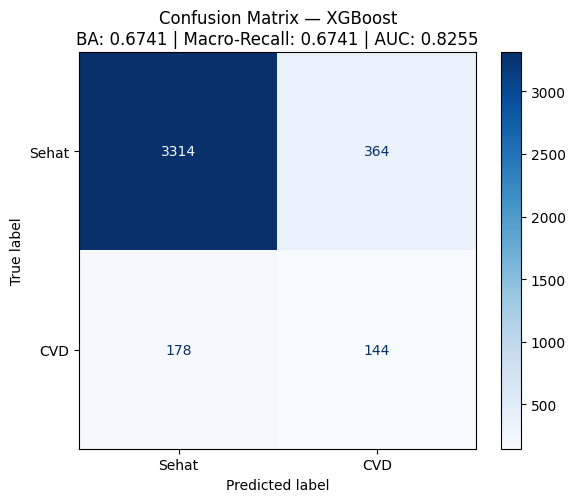


Top 30 Feature Importance:
   fitur  importance
 BPHIGH6    0.110614
 EMPLOY1    0.101408
 GENHLTH    0.057797
 TOLDHI3    0.057762
CVDSTRK3    0.044732
_AGEG5YR    0.041266
    _SEX    0.040881
CHCCOPD3    0.038930
DIABETE4    0.031590
SMOKE100    0.025327
CHOLCHK3    0.025272
PERSDOC3    0.023775
_HLTHPLN    0.022068
PNEUVAC4    0.022037
DIFFWALK    0.021019
ADDEPEV3    0.020593
_DRDXAR3    0.020100
CHECKUP1    0.018441
_DRNKWK1    0.017647
 _PRACE1    0.017358
 ASTHMA3    0.017007
  DECIDE    0.016602
   _BMI5    0.016586
MENTHLTH    0.016324
PHYSHLTH    0.016281
CHCKDNY2    0.015883
_TOTINDA    0.015639
 INCOME3    0.015438
_FRTLT1A    0.015160
FLUSHOT7    0.014848


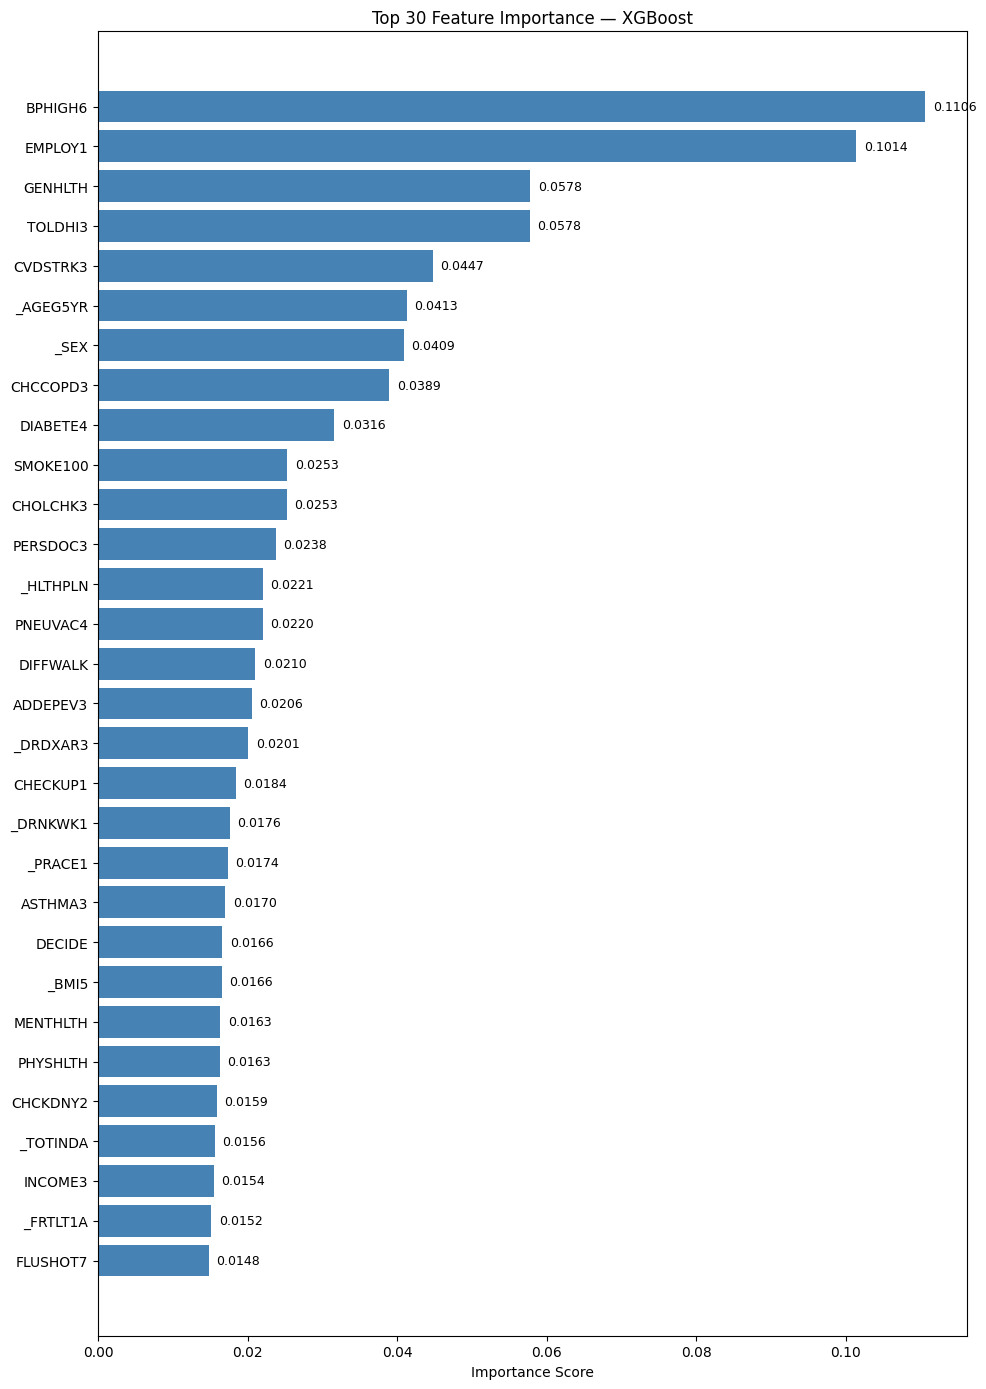

In [126]:
# ── CARA PAKAI ────────────────────────────────────────────────────────────────
results = train_evaluate_xgb(X_train, X_test, y_train, y_test)

Class distribution → Sehat: 14714, CVD: 1286
     PERFORMANCE MEASURES (Binary Classification)
  Balanced Accuracy  : 0.6741  ← METRIC UTAMA
  Macro-Recall       : 0.6741  ← METRIC UTAMA
  AUC-ROC            : 0.8255
-------------------------------------------------------
  F1-Score Macro     : 0.6357
  F1-Score Weighted  : 0.8779
  F1-Score CVD       : 0.3470
-------------------------------------------------------
  Sensitivity (CVD  ) : 0.4472
  Specificity (Sehat) : 0.9010

  TP: 144 | TN: 3314 | FP: 364 ← False Alarm | FN: 178 ← Berbahaya!

Classification Report:
              precision    recall  f1-score   support

   Sehat (0)       0.95      0.90      0.92      3678
     CVD (1)       0.28      0.45      0.35       322

    accuracy                           0.86      4000
   macro avg       0.62      0.67      0.64      4000
weighted avg       0.90      0.86      0.88      4000



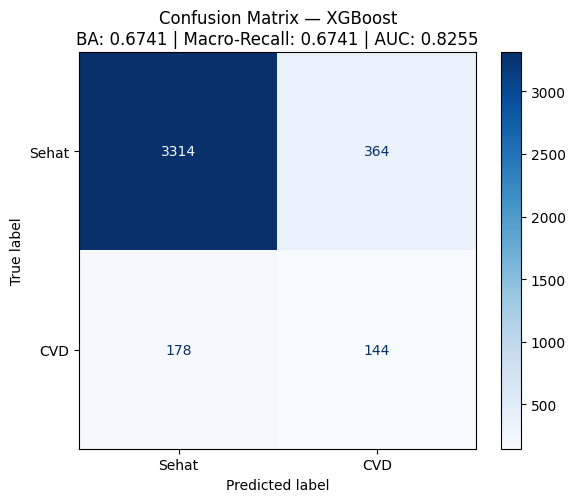


Top 30 Feature Importance:
   fitur  importance
 BPHIGH6    0.110614
 EMPLOY1    0.101408
 GENHLTH    0.057797
 TOLDHI3    0.057762
CVDSTRK3    0.044732
_AGEG5YR    0.041266
    _SEX    0.040881
CHCCOPD3    0.038930
DIABETE4    0.031590
SMOKE100    0.025327
CHOLCHK3    0.025272
PERSDOC3    0.023775
_HLTHPLN    0.022068
PNEUVAC4    0.022037
DIFFWALK    0.021019
ADDEPEV3    0.020593
_DRDXAR3    0.020100
CHECKUP1    0.018441
_DRNKWK1    0.017647
 _PRACE1    0.017358
 ASTHMA3    0.017007
  DECIDE    0.016602
   _BMI5    0.016586
MENTHLTH    0.016324
PHYSHLTH    0.016281
CHCKDNY2    0.015883
_TOTINDA    0.015639
 INCOME3    0.015438
_FRTLT1A    0.015160
FLUSHOT7    0.014848


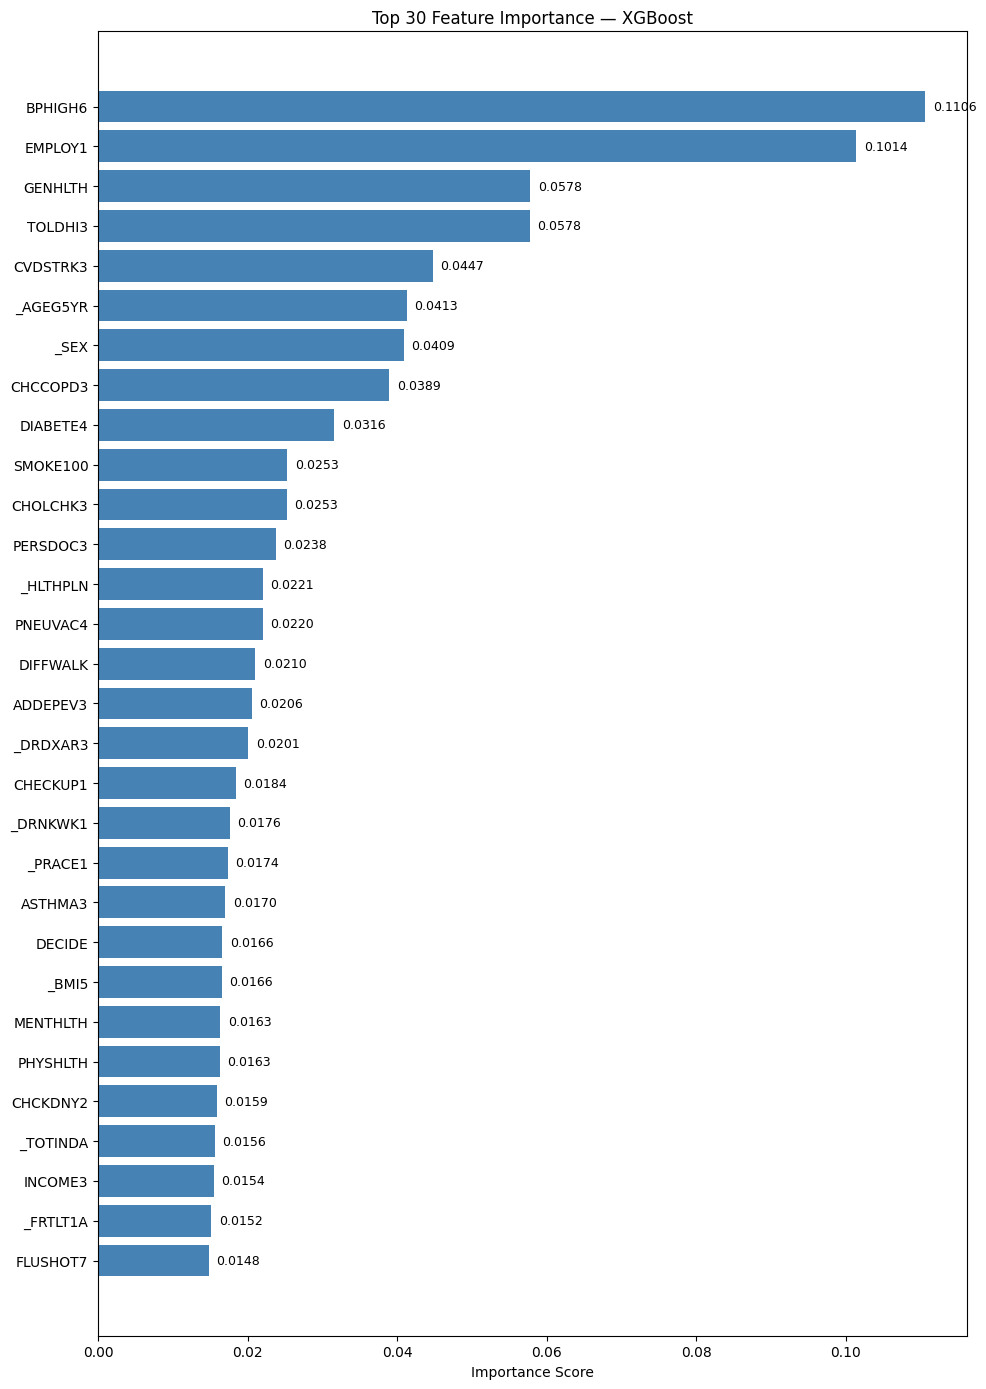

In [127]:
# ── SEKARANG bisa langsung pakai function ─────────────────────────────────────
results = train_evaluate_xgb(X_train_scaled, X_test_scaled, y_train, y_test)